In [1]:
%pip install causal-learn networkx matplotlib numpy pandas

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Descomente isso se tiver no Google Colab!!
# !git clone https://github.com/gfviegas/causality-for-data-scientists-course.git
# %cd causality-for-data-scientists-course/notebooks

# Descoberta Causal com `causal-learn`

Agora que você já está mais ambientado com o problema da descoberta casual e as terminologias de causalidade, vamos explorar o que CD (Causal Discovery) consegue (e não consegue) recuperar apenas com dados observacionais. Também vamos comparar algoritmos de famílias diferentes e como avaliar grafos descobertos com um _ground truth_ (uma espécie de "gabarito").

## Aquecimento: Conseguimos Recuperar um Grafo de 4 Nós?

Algoritmos de descoberta causal dependem (normalmente) de três hipóteses:

- **Condição de Markov Causal** — cada variável é independente de seus não-descendentes dado seus pais.
- **Fidelidade (Faithfulness)** — toda independência condicional presente nos dados é *implicada* pelo grafo, e não fruto de um cancelamento acidental de parâmetros.
- **Suficiência Causal** — não há confundidores ocultos (todas as causas comuns foram medidas).

Sob essas hipóteses, algoritmos baseados em restrições como o **PC** só conseguem recuperar a estrutura causal até uma **classe de equivalência de Markov**, representada como um **CPDAG** (Completed Partially Directed Acyclic Graph). Algumas arestas saem orientadas, outras ficam sem direção. O motivo é estrutural, não uma limitação do algoritmo.

Vamos começar com um DAG minúsculo de 4 nós cuja resposta certa já conhecemos de antemão:

$$A \to B, \quad A \to C, \quad B \to D, \quad C \to D$$

O nó $D$ é um **collider** (colisor): $B \to D \leftarrow C$ é uma v-structure *não blindada* (B e C não são adjacentes).

V-structures são o único padrão local que testes de independência condicional sempre conseguem identificar com certeza... todo o resto pode permanecer ambíguo.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import networkx as nx

np.random.seed(42)

n = 2000
A = np.random.normal(0, 1, n)
B = 0.9 * A + np.random.normal(0, 0.5, n)
C = 0.9 * A + np.random.normal(0, 0.5, n)
D = 0.8 * B + 0.8 * C + np.random.normal(0, 0.5, n)

X_warmup = np.column_stack([A, B, C, D])
names_warmup = ['A', 'B', 'C', 'D']

gt_warmup = nx.DiGraph()
gt_warmup.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'D')])

Text(0.5, 1.0, 'DAG verdadeiro (ground truth)')

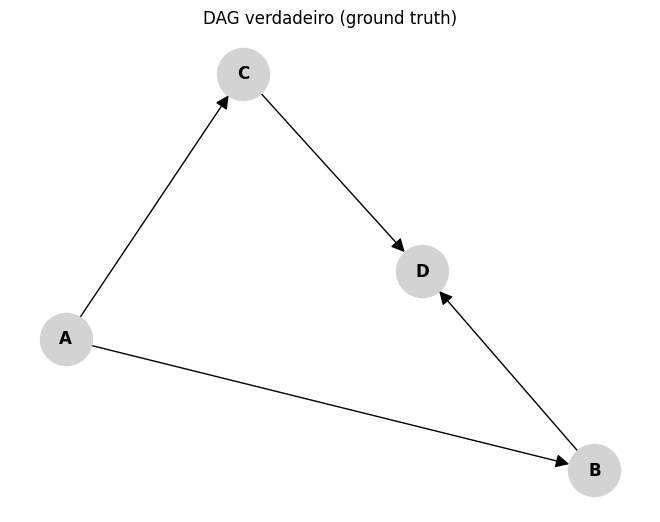

In [4]:
import matplotlib.pyplot as plt

nx.draw(gt_warmup, with_labels=True, node_size=1400, node_color='lightgray', arrowsize=20, font_weight='bold')
plt.title('DAG verdadeiro (ground truth)')

In [5]:
from causallearn.search.ConstraintBased.PC import pc

cg = pc(X_warmup, alpha=0.05, node_names=names_warmup, show_progress=False)

print('Arestas encontradas pelo PC:')
for e in cg.G.get_graph_edges():
    print(' ', e)

Arestas encontradas pelo PC:
  A --- B
  A --- C
  B --> D
  C --> D


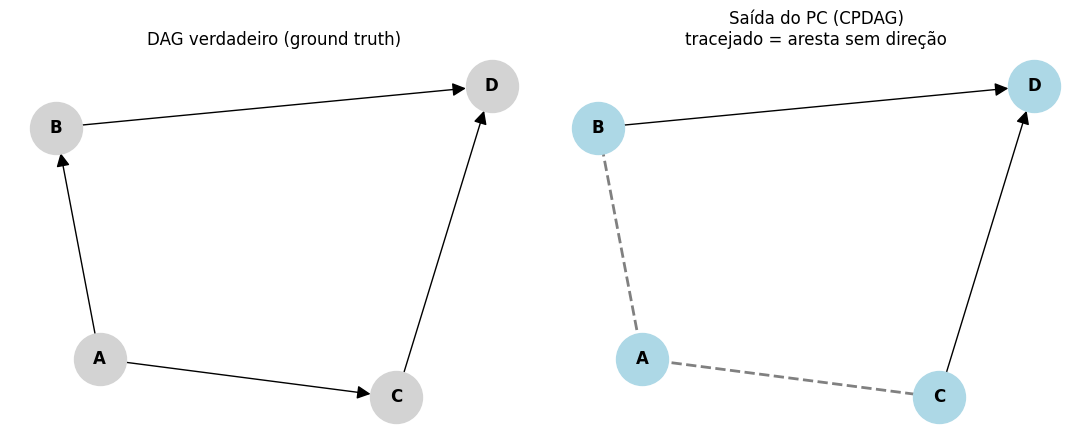

In [6]:
def cl_edges_to_nx(G):
    """Converte um GeneralGraph do causal-learn em uma lista de tuplas (node1, node2, mark1, mark2), onde mark é 'ARROW' ou 'TAIL'. TAIL-ARROW significa node1 -> node2. TAIL-TAIL significa uma aresta sem direção."""
    out = []
    for e in G.get_graph_edges():
        n1, n2 = e.get_node1().get_name(), e.get_node2().get_name()
        m1 = 'ARROW' if 'ARROW' in str(e.get_endpoint1()) else 'TAIL'
        m2 = 'ARROW' if 'ARROW' in str(e.get_endpoint2()) else 'TAIL'
        out.append((n1, n2, m1, m2))
    return out

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
pos = nx.spring_layout(gt_warmup, seed=1)

nx.draw(gt_warmup, pos, ax=axes[0], with_labels=True, node_size=1400, node_color='lightgray', arrowsize=20, font_weight='bold')
axes[0].set_title('DAG verdadeiro (ground truth)')

# Desenha a saída do PC: arestas direcionadas como setas, arestas sem direção (TAIL-TAIL) como linhas simples
directed = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(cg.G) if m1 == 'TAIL' and m2 == 'ARROW']
undirected = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(cg.G) if m1 == 'TAIL' and m2 == 'TAIL']

G_out = nx.DiGraph()
G_out.add_nodes_from(names_warmup)
G_out.add_edges_from(directed)
nx.draw(G_out, pos, ax=axes[1], with_labels=True, node_size=1400, node_color='lightblue',
        arrowsize=20, font_weight='bold')
nx.draw_networkx_edges(nx.Graph(undirected), pos, ax=axes[1], edge_color='gray', style='dashed', width=2)
axes[1].set_title('Saída do PC (CPDAG)\ntracejado = aresta sem direção')

plt.tight_layout()
plt.savefig('../figures/2_warmup_cpdag.png', dpi=120, bbox_inches='tight')
plt.show()

Exatamente como previsto: o PC orienta **B → D** e **C → D**, que é a v-structure no collider. Entretanto, ele deixa **A – B** e **A – C** sem direção.

$A$ é um *fork* (bifurcação, causa comum de $B$ e $C$), e um fork sozinho não produz nenhuma assinatura de independência condicional que distinga "A causa B" de "B causa A" sem hipóteses extras (como ruído não-Gaussiano, como no LiNGAM - outro algoritmo de CD).

Essa é uma demonstração do limite real do que um teste observacional de independência condicional consegue nos dizer.

## O Dataset de Sinalização de Proteínas de Sachs

Nosso benchmark principal é o dataset de citometria de fluxo de **Sachs et al. (2005)**: níveis de expressão de 11 proteínas/lipídios fosforilados em células imunes humanas, medidos sob diferentes perturbações experimentais.

É um dos poucos datasets reais em que o grafo causal é conhecido de forma independente. O gabarito (ground truth) foi estabelecido pelos próprios autores usando experimentos intervencionistas (e não apenas raciocínio correlacional), o que é exatamente o que nos permite avaliar um algoritmo de descoberta contra uma resposta real, em vez de uma sintética.

- **11 variáveis:** `raf, mek, plc, pip2, pip3, erk, akt, pka, pkc, p38, jnk`
- **7.466 observações**
- **20 arestas direcionadas** no grafo-gabarito de consenso publicado

In [7]:
import pandas as pd

sachs = pd.read_csv('../datasets/3_causal_discovery/sachs.csv')
print('Formato:', sachs.shape)
sachs.describe().T[['mean', 'std', 'min', 'max']]

Formato: (7466, 11)


,mean,std,min,max
raf,124.071930,247.528092,1.0,4614.0
mek,145.380962,377.056214,1.0,7105.0
plc,54.853643,173.859778,1.0,6208.0
pip2,151.120738,299.347505,1.0,9058.0
pip3,27.034962,43.048160,1.0,1275.0
erk,26.631193,45.826718,1.0,2571.0
akt,81.167214,137.766206,1.0,3555.0
pka,625.758588,644.459352,1.0,8896.0
pkc,30.341658,92.870039,1.0,1611.0
p38,135.014504,494.768842,1.0,7499.0


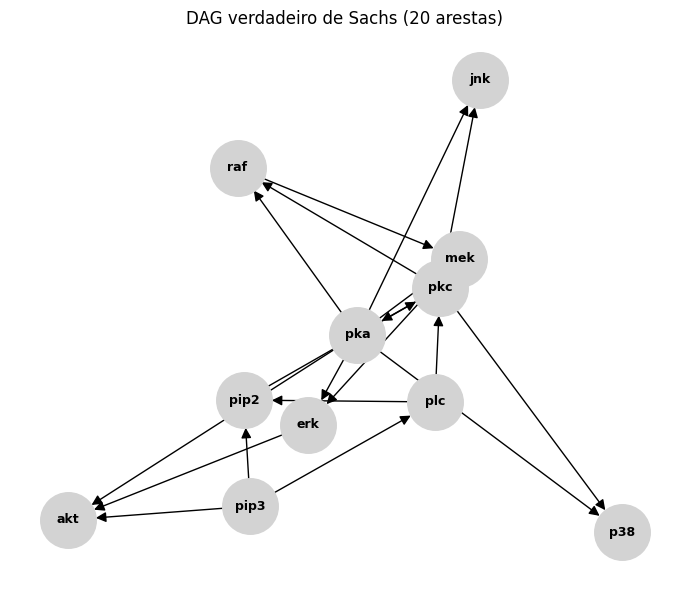

In [8]:
# Grafo-gabarito (ground truth), publicado em Sachs et al. (2005) e distribuído por
# https://github.com/cmu-phil/example-causal-datasets
gt_edges = [
    ('raf', 'mek'), ('pka', 'raf'), ('pka', 'mek'), ('pka', 'jnk'), ('pka', 'p38'),
    ('pka', 'akt'), ('pka', 'erk'), ('pkc', 'raf'), ('pkc', 'mek'), ('pkc', 'jnk'),
    ('pkc', 'p38'), ('pkc', 'pka'), ('mek', 'erk'), ('erk', 'akt'), ('plc', 'pip2'),
    ('plc', 'pkc'), ('pip3', 'pip2'), ('pip3', 'plc'), ('pip3', 'akt'), ('pip2', 'pkc'),
]

gt_graph = nx.DiGraph()
gt_graph.add_nodes_from(sachs.columns)
gt_graph.add_edges_from(gt_edges)

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.spring_layout(gt_graph, seed=7, k=0.9)
nx.draw(gt_graph, pos, ax=ax, with_labels=True, node_size=1600, node_color='lightgray',
        arrowsize=15, font_weight='bold', font_size=9)
ax.set_title(f'DAG verdadeiro de Sachs ({len(gt_edges)} arestas)')
plt.tight_layout()
plt.savefig('../figures/2_sachs_ground_truth.png', dpi=120, bbox_inches='tight')
plt.show()

## Rodando o PC no Sachs

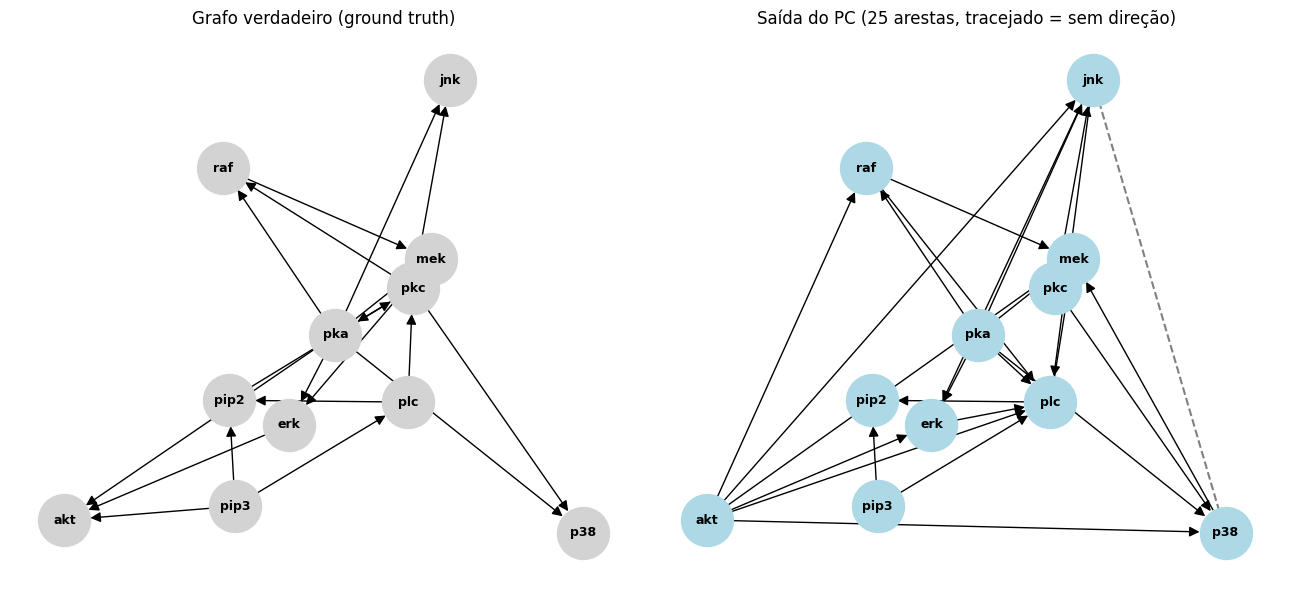

In [9]:
cg_sachs = pc(sachs.values, alpha=0.05, node_names=list(sachs.columns), show_progress=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
nx.draw(gt_graph, pos, ax=axes[0], with_labels=True, node_size=1400, node_color='lightgray',
        arrowsize=15, font_weight='bold', font_size=9)
axes[0].set_title('Grafo verdadeiro (ground truth)')

pc_directed = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(cg_sachs.G) if m1 == 'TAIL' and m2 == 'ARROW']
pc_undirected = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(cg_sachs.G) if m1 == 'TAIL' and m2 == 'TAIL']

G_pc = nx.DiGraph()
G_pc.add_nodes_from(sachs.columns)
G_pc.add_edges_from(pc_directed)
nx.draw(G_pc, pos, ax=axes[1], with_labels=True, node_size=1400, node_color='lightblue',
        arrowsize=15, font_weight='bold', font_size=9)
nx.draw_networkx_edges(nx.Graph(pc_undirected), pos, ax=axes[1], edge_color='gray', style='dashed', width=1.5)
axes[1].set_title(f'Saída do PC ({len(pc_directed) + len(pc_undirected)} arestas, tracejado = sem direção)')

plt.tight_layout()
plt.savefig('../figures/2_sachs_pc_output.png', dpi=120, bbox_inches='tight')
plt.show()

### Mini-quiz
Antes de seguir, responda mentalmente:

1. Você consegue dizer se esse grafo é bom?
2. Que tipo de métrica você utilizaria pra comparar esses grafos?

## Comparando Grafos

Normalmente escreve-se funções customizadas de pontuação, já que comparar CPDAGs não é um conceito universal. Afinal, o que é mais importante: ter menos arestas erradas? Ter mais arestar corretas? Ter uma taxa maior de direcionamento de arestas? Etc.

Apesar dessa ambiguidade algumas métricas são comuns de serem coletadas e reportadas:
- **Precisão/recall de esqueleto (skeleton)**: trata cada aresta como presente/ausente, ignorando a direção. `Precisão = arestas encontradas corretamente / todas as arestas encontradas`. `Recall = arestas encontradas corretamente / todas as arestas verdadeiras`.
- **Acurácia de orientação**: entre as arestas de esqueleto que acertamos, quantas estão orientadas (não deixadas sem direção) e, dessas, quantas apontam para o lado correto?
- **SHD (Structural Hamming Distance / Distância de Hamming Estrutural)**: o número de inserções, remoções e inversões de orientação de arestas necessárias para transformar nossa saída no gabarito: `SHD = falsos_positivos + falsos_negativos + orientações_erradas`.

In [10]:
def score_graph(edges, gt_edges):
    """edges: list of (n1, n2, mark1, mark2) from cl_edges_to_nx(). gt_edges: list of (parent, child)."""
    gt_skeleton = set(frozenset(e) for e in gt_edges)
    gt_directed = set(gt_edges)

    found_skeleton = set(frozenset((n1, n2)) for n1, n2, _, _ in edges)
    tp = len(found_skeleton & gt_skeleton)
    fp = len(found_skeleton - gt_skeleton)
    fn = len(gt_skeleton - found_skeleton)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    oriented, correct = 0, 0
    for n1, n2, m1, m2 in edges:
        if frozenset((n1, n2)) not in gt_skeleton:
            continue
        if m1 == 'TAIL' and m2 == 'ARROW':          # n1 -> n2
            oriented += 1
            correct += (n1, n2) in gt_directed
        elif m1 == 'ARROW' and m2 == 'TAIL':          # n2 -> n1
            oriented += 1
            correct += (n2, n1) in gt_directed

    shd = fp + fn + (oriented - correct)
    return {
        'true_positive_edges': tp, 'false_positive_edges': fp, 'false_negative_edges': fn,
        'precision': round(precision, 2), 'recall': round(recall, 2),
        'oriented_of_correct_skeleton': oriented, 'correctly_oriented': correct,
        'SHD': shd,
    }

pc_score = score_graph(cl_edges_to_nx(cg_sachs.G), gt_edges)
pc_score

{'true_positive_edges': 12,
 'false_positive_edges': 13,
 'false_negative_edges': 8,
 'precision': 0.48,
 'recall': 0.6,
 'oriented_of_correct_skeleton': 12,
 'correctly_oriented': 11,
 'SHD': 22}

## Testando outro algoritmo...

### Descoberta Baseada em Pontuação: o GES
O **GES (Greedy Equivalence Search, ou Busca Gulosa por Equivalência)** segue uma abordagem diferente: em vez de testar independências condicionais aresta por aresta, ele busca diretamente no espaço de CPDAGs com uma fase para frente (adicionar arestas) e uma fase para trás (remover arestas), maximizando gulosamente uma pontuação de "veracidade penalizada" (BIC, por padrão) a cada passo.

> **Nota de compatibilidade:** a versão instalada do `causal-learn` tem um pequeno bug no código de pontuação BIC que só aparece com NumPy ≥ 2.0 (`float()` em um array 1×1 deixou de ser implícito). Corrigimos essa única função abaixo. isso não muda nada do algoritmo, apenas resolve uma incompatibilidade de versão do NumPy.

In [11]:
import causallearn.search.ScoreBased.GES as GES_mod

def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    cov, n = Data
    lambda_value = 0.5 if parameters is None else parameters['lambda_value']
    sigma = cov[i, i]
    if len(PAi) > 0:
        yX = cov[np.ix_([i], PAi)]
        XX = cov[np.ix_(PAi, PAi)]
        try:
            XX_inv = np.linalg.inv(XX)
        except np.linalg.LinAlgError:
            XX_inv = np.linalg.pinv(XX)
        diff = cov[i, i] - yX @ XX_inv @ yX.T
        sigma = float(np.asarray(diff).reshape(-1)[0])   # Extração de escalar segura para NumPy 2.x
    if sigma <= 0:
        sigma = np.finfo(float).eps
    likelihood = -0.5 * n * (1 + np.log(sigma))
    penalty = lambda_value * (len(PAi) + 1) * np.log(n)
    return likelihood - penalty

GES_mod.local_score_BIC_from_cov = local_score_BIC_from_cov

In [12]:
ges_result = GES_mod.ges(sachs.values, node_names=list(sachs.columns))

ges_result['G']

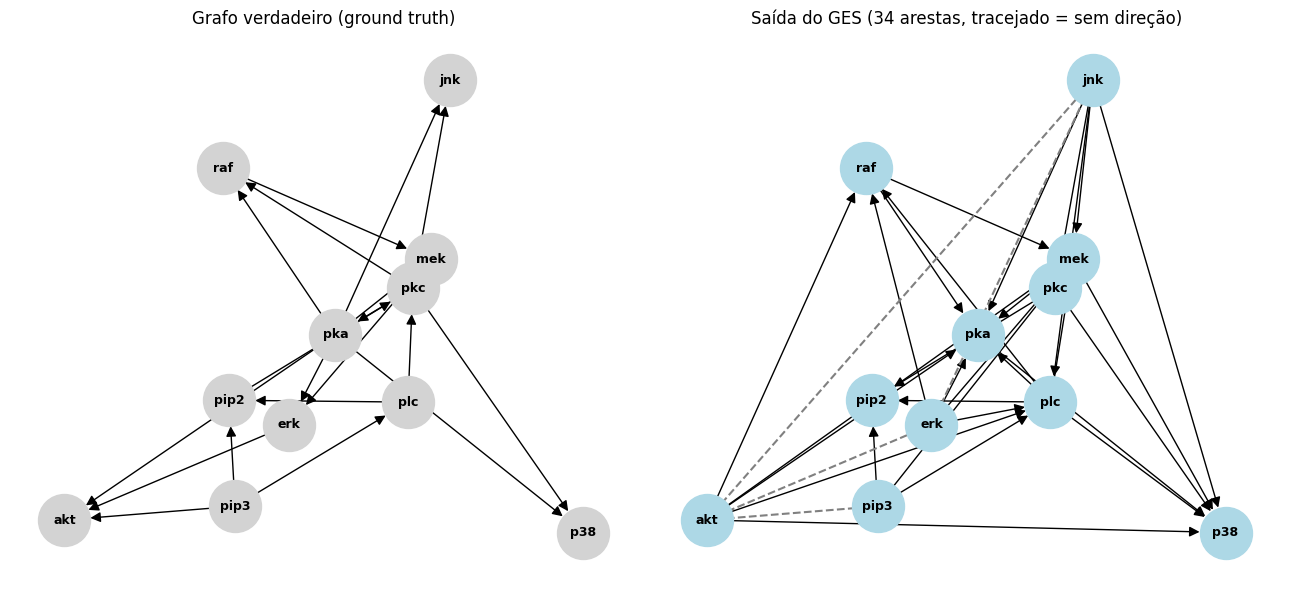

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
nx.draw(gt_graph, pos, ax=axes[0], with_labels=True, node_size=1400, node_color='lightgray', arrowsize=15, font_weight='bold', font_size=9)
axes[0].set_title('Grafo verdadeiro (ground truth)')

ges_directed = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(ges_result['G']) if m1 == 'TAIL' and m2 == 'ARROW']
ges_undirected = [(n1, n2) for n1, n2, m1, m2 in cl_edges_to_nx(ges_result['G']) if m1 == 'TAIL' and m2 == 'TAIL']

G_pc = nx.DiGraph()
G_pc.add_nodes_from(sachs.columns)
G_pc.add_edges_from(ges_directed)
nx.draw(G_pc, pos, ax=axes[1], with_labels=True, node_size=1400, node_color='lightblue',
        arrowsize=15, font_weight='bold', font_size=9)
nx.draw_networkx_edges(nx.Graph(ges_undirected), pos, ax=axes[1], edge_color='gray', style='dashed', width=1.5)
axes[1].set_title(f'Saída do GES ({len(ges_directed) + len(ges_undirected)} arestas, tracejado = sem direção)')

plt.tight_layout()
plt.savefig('../figures/2_sachs_ges_output.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
ges_score = score_graph(cl_edges_to_nx(ges_result['G']), gt_edges)

comparison = pd.DataFrame({'PC': pc_score, 'GES': ges_score}).T
comparison

,true_positive_edges,false_positive_edges,false_negative_edges,precision,recall,oriented_of_correct_skeleton,correctly_oriented,SHD
PC,12.0,13.0,8.0,0.48,0.60,12.0,11.0,22.0
GES,17.0,17.0,3.0,0.50,0.85,15.0,6.0,29.0


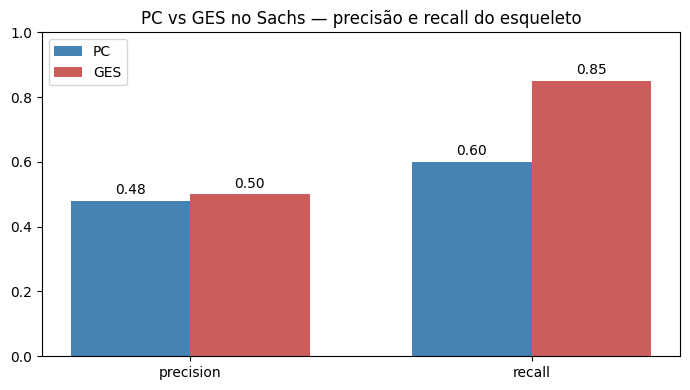

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics_to_plot = ['precision', 'recall']
x = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x - width/2, comparison.loc['PC', metrics_to_plot], width, label='PC', color='steelblue')
ax.bar(x + width/2, comparison.loc['GES', metrics_to_plot], width, label='GES', color='indianred')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title('PC vs GES no Sachs — precisão e recall do esqueleto')
ax.legend()
for i, m in enumerate(metrics_to_plot):
    ax.text(i - width/2, comparison.loc['PC', m] + 0.02, f"{comparison.loc['PC', m]:.2f}", ha='center')
    ax.text(i + width/2, comparison.loc['GES', m] + 0.02, f"{comparison.loc['GES', m]:.2f}", ha='center')
plt.tight_layout()
plt.savefig('../figures/2_pc_vs_ges.png', dpi=120, bbox_inches='tight')
plt.show()

Nesse dataset, o **GES recupera mais do esqueleto verdadeiro do que o PC** (recall mais alto). Ele está mais disposto a adicionar arestas na busca. Mas isso tem um custo: mais falsos positivos e, principalmente, uma **acurácia de orientação bem pior** nas arestas que compartilha com o PC.

O efeito líquido é um **SHD maior (pior) para o GES do que para o PC**, mesmo com o recall bruto do GES parecendo melhor isoladamente.

Como citamos no início, nenhuma métrica isolada conta a história toda, e "encontrou mais arestas verdadeiras" não é o mesmo que "produziu um grafo mais útil". E vice-versa.

## Extra: Injetando Conhecimento de Domínio

Algoritmos de descoberta não precisam trabalhar só com os dados. A classe `BackgroundKnowledge` do `causal-learn` permite proibir ou exigir arestas direcionadas específicas antes de rodar a busca. Essa é uma implementação direta do ponto do capítulo de que *"pesquisadores costumam ... usar conhecimento de domínio para restringir o espaço de busca."*

Olhando a saída do PC sem restrições acima, uma aresta é um erro claro de domínio: o PC orientou **`akt → raf`**, mas, biologicamente, o `raf` está bem a montante (upstream) na via MAPK/AKT, e portanto ele não deveria ser *causado por* `akt`. 

Vamos proibir essa direção específica e ver como a busca reage.

In [16]:
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

bk = BackgroundKnowledge()
bk.add_forbidden_by_node(GraphNode('akt'), GraphNode('raf'))   # proíbe akt -> raf

cg_constrained = pc(sachs.values, alpha=0.05, node_names=list(sachs.columns), background_knowledge=bk, show_progress=False)

print('Arestas que tocam "raf" SEM a restrição:')
for n1, n2, m1, m2 in cl_edges_to_nx(cg_sachs.G):
    if 'raf' in (n1, n2):
        arrow = '->' if (m1, m2) == ('TAIL', 'ARROW') else ('<-' if (m1, m2) == ('ARROW', 'TAIL') else '--')
        print(f'  {n1} {arrow} {n2}')

print('\nArestas que tocam "raf" COM a restrição akt-/->raf:')
for n1, n2, m1, m2 in cl_edges_to_nx(cg_constrained.G):
    if 'raf' in (n1, n2):
        arrow = '->' if (m1, m2) == ('TAIL', 'ARROW') else ('<-' if (m1, m2) == ('ARROW', 'TAIL') else '--')
        print(f'  {n1} {arrow} {n2}')

Arestas que tocam "raf" SEM a restrição:
  raf -> mek
  raf -> plc
  akt -> raf
  pka -> raf

Arestas que tocam "raf" COM a restrição akt-/->raf:
  raf -> mek
  raf -> plc
  raf -> akt
  raf -> pka


A aresta proibida é reorientada como **`raf → akt`** em vez de ser descartada. O algoritmo mantém a dependência estatística que encontrou, mas respeita a restrição de direção.

Note também que **`pka–raf` também se inverte** (ela vai da correta `pka → raf` para a incorreta `raf → pka`): uma única restrição de conhecimento de domínio se propaga pelas regras de orientação do PC e pode mudar arestas em outras partes do grafo, para melhor ou para pior.

Conhecimento de domínio é uma ferramenta poderosa, mas precisa ser aplicado com cautela e revalidado contra as métricas, não apenas afirmado e aceito de olhos fechados (a não ser que fornecida por um especialista).

## Concluindo...

### 1. Descoberta entrega uma classe de equivalência, não o gabarito

Mesmo no aquecimento de 4 nós sem ruído, o PC não conseguiu orientar o fork em $A$, mas sim só o collider em $D$. 

Nos dados reais de Sachs, tanto o PC quanto o GES deixaram várias arestas sem direção ou as orientaram incorretamente.

**Um CPDAG é a saída honesta da descoberta causal observacional. Trate-o como uma hipótese, não como uma resposta.**

### 2. Nenhum algoritmo ou métrica isolada domina sozinho

O GES encontrou mais do esqueleto verdadeiro (recall mais alto), mas um SHD geral *pior* do que o PC, porque suas arestas extras e erros de orientação superaram o ganho de recall.

Famílias diferentes de algoritmos (baseados em restrições, em pontuação, funcionais) fazem trade-offs diferentes. Rode mais de um e compare, como fizemos aqui.

### 3. Conhecimento de domínio e descoberta são complementares, não substitutos

As restrições do `BackgroundKnowledge` permitem injetar o que você já sabe (por exemplo, reguladores upstream conhecidos) diretamente na busca, e o algoritmo ainda precisa reconciliar esse conhecimento com todo o resto dos dados, às vezes com efeitos colaterais em arestas não relacionadas.

O melhor jeito de ler a saída da descoberta é como **um ponto de partida para as etapas de identificação e estimação que vêm a seguir**, refinado justamente por esse tipo de conhecimento de domínio.